,country,country_code,year,health_exp,life_expect,maternal_mortality,infant_mortality,neonatal_mortality,under_5_mortality,prev_hiv,inci_tuberc,prev_undernourishment,entity_type
0,Afghanistan,AFG,1999,9.443391,54.846,1346.0,94.6,64.0,135.8,0.1,190.0,46.0,country
1,Afghanistan,AFG,2000,9.443391,55.298,1346.0,92.0,62.7,131.6,0.1,190.0,46.0,country
2,Afghanistan,AFG,2001,9.443391,55.798,1273.0,89.3,61.5,127.4,0.1,189.0,46.0,country
3,Afghanistan,AFG,2002,9.443391,56.454,1277.0,86.6,60.2,123.0,0.1,189.0,43.7,country
4,Afghanistan,AFG,2003,8.941258,57.344,1196.0,83.7,58.9,118.5,0.1,189.0,38.6,country


              year   health_exp  life_expect  maternal_mortality  \
count  6650.000000  5950.000000  6500.000000         5825.000000   
mean   2011.000000     6.247958    70.195931          197.812532   
std       7.211645     2.880088     8.630378          264.506961   
min    1999.000000     1.107200    41.957000            1.000000   
25%    2005.000000     4.225656    64.691061           18.000000   
50%    2011.000000     5.466316    71.910378           74.000000   
75%    2017.000000     7.870093    76.717750          286.000000   
max    2023.000000    24.283052    85.532683         1687.000000   

       infant_mortality  neonatal_mortality  under_5_mortality     prev_hiv  \
count       6100.000000         6100.000000        6100.000000  4550.000000   
mean          28.622262           16.251410          39.852417     1.772446   
std           25.281243           12.549483          40.491624     3.946630   
min            1.300000            0.700000           1.500000     0.10

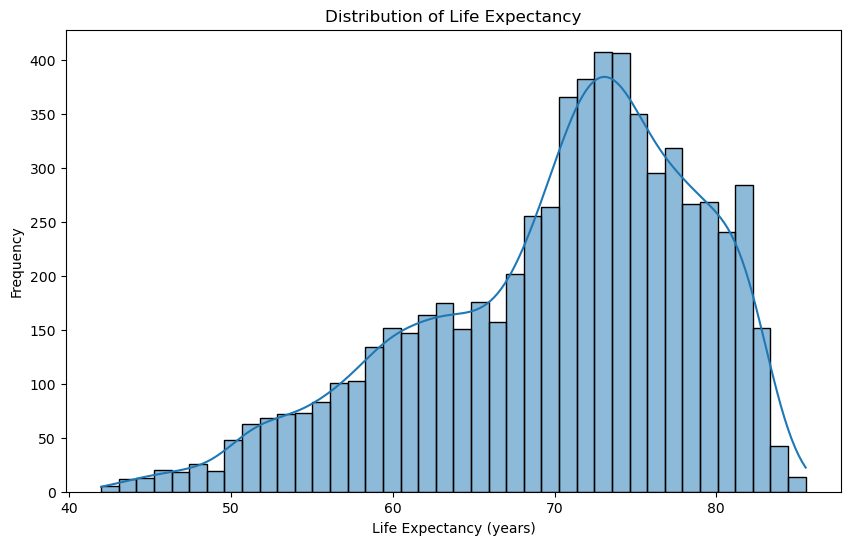

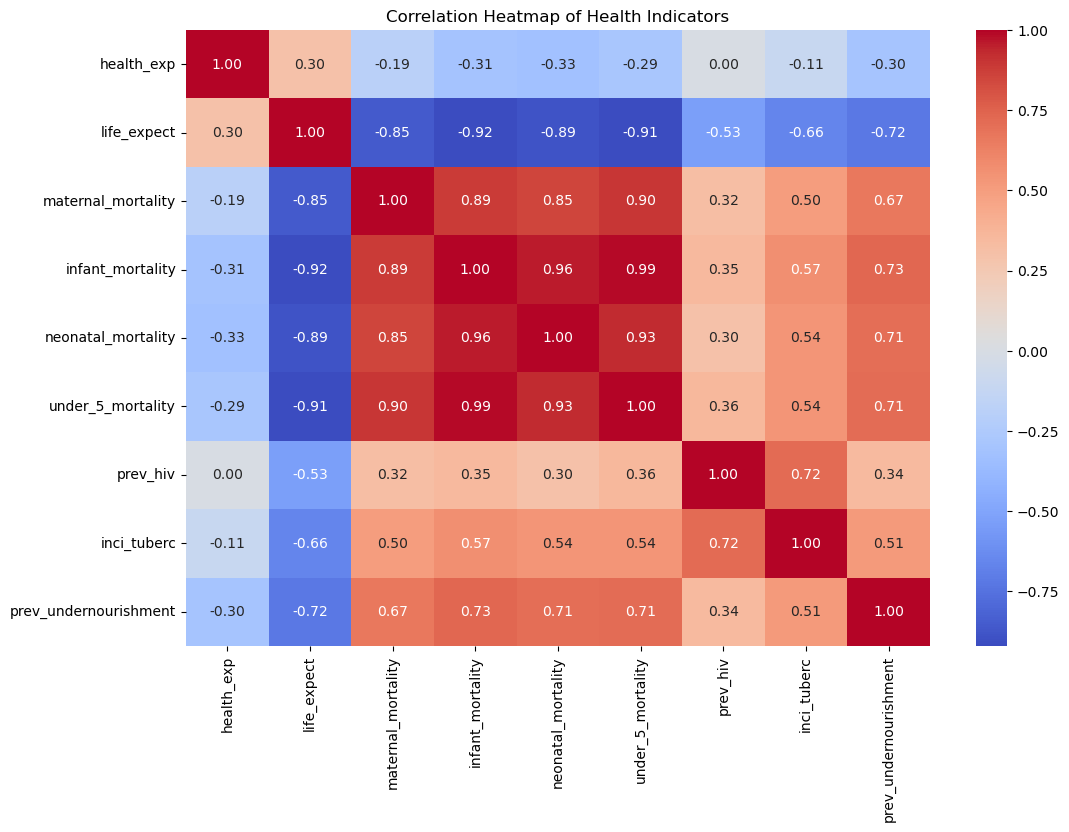

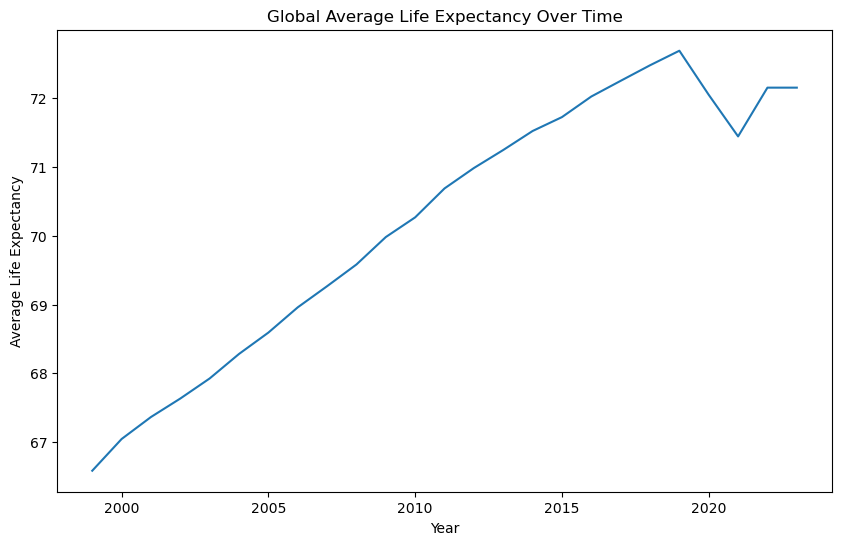

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_csv("cleaned_world_health_data.csv")

# Basic info
display(df.head())
print(df.describe())
print(df["country"].nunique(), "unique countries")

# Year range
print("Year range:", df["year"].min(), "to", df["year"].max())

# 1. Distribution of life expectancy
plt.figure(figsize=(10, 6))
sns.histplot(df["life_expect"], kde=True, bins=40)
plt.title("Distribution of Life Expectancy")
plt.xlabel("Life Expectancy (years)")
plt.ylabel("Frequency")
plt.show()

# 2. Correlation heatmap of all indicators
plt.figure(figsize=(12, 8))
sns.heatmap(df.drop(columns=["year"]).select_dtypes(include='number').corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Health Indicators")
plt.show()

# 3. Trend of global average life expectancy
plt.figure(figsize=(10, 6))
sns.lineplot(data=df.groupby("year")["life_expect"].mean().reset_index(), x="year", y="life_expect")
plt.title("Global Average Life Expectancy Over Time")
plt.xlabel("Year")
plt.ylabel("Average Life Expectancy")
plt.show()